# 02 - Analisis de datos y limpieza

## Trabajo guiado
Construcción de variables base (precio, superficie, ambientes, dormitorios, baños, cocheras, barrio y zona), filtros de calidad, ingeniería de features y gráficos descriptivos para informe universitario.

## Procesamiento

### Extracción de features desde campos base
- **Price** -> currency, price_val
- **Features** -> surface_total, rooms, bedrooms, bathrooms, garage
- **Location** -> barrio, barrio_norm, zona
- **Description** -> 6 amenities (garage, ascensor, balcon, patio, lavadero, aire_acondicionado), cantidad_amenities

### Cálculos y categorización
- **price_m2** = price_val / surface_total
- **segmento_precio** = terciles empíricos de price_m2 (Económico/Medio/Premium)

### Filtros de calidad
- Descartar moneda "Consultar"
- Descartar price_val <= 0 o nulo
- Descartar surface_total <= 0 o nulo
- Remover outliers de price_m2 usando IQR robusto por type_operation

## Variables derivadas construidas para el análisis

A partir del dataset original se construyeron las siguientes variables mediante procesamiento en Python (equivalente metodológico al flujo en R):

| Variable | Descripción |
|---|---|
| `currency` | Moneda del precio extraída de `Price` (USD, ARS, Consultar) |
| `price_val` | Valor numérico del precio |
| `surface_total` | Superficie total en m², extraída de `Features` (regex) |
| `rooms` | Ambientes |
| `bedrooms` | Dormitorios extraídos de `Features` (regex) |
| `bathrooms` | Baños extraídos de `Features` (regex) |
| `garage` | Cocheras extraídas de `Features` (regex) |
| `price_m2` | Precio por m² = `price_val / surface_total` |
| `barrio` | Barrio extraído de `Location` (texto antes de la primera coma) |
| `zona` | Macrozona: Centro / Norte / Oeste / Sur / Otro |
| `segmento_precio` | Terciles empíricos de `price_m2`: Económico (< P33) / Medio (P33-P67) / Premium (> P67) |

## Salidas esperadas
- Dataset limpio base con features: outputs/interim/02_df_limpio_base.csv
- Tabla de calidad: outputs/tablas/02_reporte_calidad.csv
- Gráficos: outputs/graficos/02_*.png (price_m2, segmento_precio, amenities)

### Parametros

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parametros paths
out_interm = Path('outputs/interm')
out_tablas = Path('outputs/tablas')
out_graficos = Path('outputs/graficos')

In [2]:
in_path = out_interm / '01_df_scope.csv'
df = pd.read_csv(in_path)
print('Filas input:', len(df), '| Columnas:', df.shape[1])

Filas input: 108034 | Columnas: 13


## Procesar Variables

### Price

In [3]:
# Funciones de parseo para variables clave

def parse_currency(price: str):
    """Extrae moneda desde campo Price"""
    if pd.isna(price):
        return np.nan
    s = str(price).lower()
    if 'consultar' in s:
        return 'Consultar'
    if 'usd' in s or 'u$s' in s or 'us$' in s:
        return 'USD'
    if 'ars' in s or '$' in s:
        return 'ARS'
    return np.nan

def parse_price_val(price: str):
    """Extrae valor numérico de precio"""
    if pd.isna(price):
        return np.nan
    m = re.findall(r'\d[\d\.,]*', str(price))
    if not m:
        return np.nan
    n = m[0].replace('.', '').replace(',', '.')
    return pd.to_numeric(n, errors='coerce')
    
def parse_surface_total(features: str):
    """Extrae superficie total desde Features"""
    if pd.isna(features):
        return np.nan
    m = re.search(r'(\d+[\.,]?\d*)\s*m', str(features).lower())
    if not m:
        return np.nan
    n = m.group(1).replace('.', '').replace(',', '.')
    return pd.to_numeric(n, errors='coerce')

In [4]:
df_limpio = df.copy()
df_limpio['currency'] = df_limpio['Price'].apply(parse_currency)
df_limpio['price_val'] = df_limpio['Price'].apply(parse_price_val)
df_limpio['surface_total'] = df_limpio['Features'].apply(parse_surface_total)

# Aplicar filtros de calidad básicos
f_currency = ~df_limpio['currency'].eq('Consultar')
f_price = df_limpio['price_val'].notna() & (df_limpio['price_val'] > 0)
f_surface = df_limpio['surface_total'].notna() & (df_limpio['surface_total'] > 0)

df_base = df_limpio.loc[f_currency & f_price & f_surface].copy()
df_base['price_m2'] = df_base['price_val'] / df_base['surface_total']

print('Filas post filtros básicos:', len(df_base))

Filas post filtros básicos: 107191


## Filtrado de outliers por operacion

In [5]:
def filtrar_iqr(g: pd.DataFrame) -> pd.DataFrame:
    """Elimina outliers usando IQR robusto por tipo de operación"""
    q1 = g['price_m2'].quantile(0.25)
    q3 = g['price_m2'].quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return g
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    return g[(g['price_m2'] >= li) & (g['price_m2'] <= ls)]

df_final = (
    df_base.groupby('type_operation', group_keys=False)
    .apply(filtrar_iqr)
    .reset_index(drop=True)
)

pct_retencio = round(100 * len(df_final) / len(df_base), 2)
print(f'Filas post outliers (IQR): {len(df_final)} ({pct_retencio}% retencion)')

Filas post outliers (IQR): 104084 (97.1% retencion)


/tmp/ipykernel_1399/977620778.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_iqr)


## Feature engineering: lógica de Features + barrio/zona + amenities

In [6]:
import unicodedata

def norm_text(s: str) -> str:
    """Normaliza texto: minuscula, sin acentos, espacios simples."""
    if pd.isna(s):
        return ''
    x = str(s).strip().lower()
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('ascii')
    x = re.sub(r'\s+', ' ', x)
    return x


def limpiar_features(features: str) -> str:
    """Limpia el string de Features removiendo corchetes/comillas."""
    if pd.isna(features):
        return ''
    x = str(features)
    x = x.replace('[', '').replace(']', '').replace("'", '')
    return x


def parse_feature_num(features: str, pattern: str) -> float:
    """Extrae número por regex lookahead, siguiendo lógica de R."""
    cleaned = limpiar_features(features)
    if not cleaned:
        return np.nan
    m = re.search(pattern, cleaned, flags=re.IGNORECASE)
    if not m:
        return np.nan
    return pd.to_numeric(m.group(0), errors='coerce')


# Extracción principal replicando la lógica del Rmd
df_final['surface_total'] = df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*m²\s*tot\.)'))
df_final['rooms'] = df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*amb\.)'))
df_final['bedrooms'] = df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*dorm\.)'))
df_final['bathrooms'] = df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*bañ?os?)'))
df_final['garage'] = df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*coch\.)'))

# Fallbacks para tolerar variantes de scraping en Features
df_final['surface_total'] = df_final['surface_total'].fillna(
    df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*m2\s*tot\.)'))
)
df_final['bedrooms'] = df_final['bedrooms'].fillna(
    df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*dormitorios?)'))
)
df_final['bathrooms'] = df_final['bathrooms'].fillna(
    df_final['Features'].apply(lambda x: parse_feature_num(x, r'\d+(?=\s*baños?)'))
)

print('NAs por variable extraida desde Features:')
for col in ['surface_total', 'rooms', 'bedrooms', 'bathrooms', 'garage']:
    n_na = int(df_final[col].isna().sum())
    pct_na = round(100 * n_na / len(df_final), 2)
    print(f'  {col}: {n_na} ({pct_na}%)')


# 2. SEGMENTO DE PRECIO por terciles (separado por operación)
def categorizar_precio(group):
    """Categoriza price_m2 por terciles dentro de cada operación."""
    tercil_33 = group['price_m2'].quantile(0.33)
    tercil_66 = group['price_m2'].quantile(0.66)

    def asignar_cat(x):
        if x <= tercil_33:
            return 'Bajo'
        if x <= tercil_66:
            return 'Medio'
        return 'Alto'

    return group['price_m2'].apply(asignar_cat)


df_final['precio_categoria'] = df_final.groupby('type_operation', group_keys=False)['price_m2'].transform(
    lambda g: categorizar_precio(df_final.loc[g.index])
)

# Variable alineada con nomenclatura del trabajo base (Rmd)
map_segmento = {'Bajo': 'Económico', 'Medio': 'Medio', 'Alto': 'Premium'}
df_final['segmento_precio'] = df_final['precio_categoria'].map(map_segmento)


# 3. AMENITIES desde Description
def extraer_amenities(desc: str) -> dict:
    """Extrae presencia de amenities del campo Description."""
    amenities = {
        'garage': 0,
        'ascensor': 0,
        'balcon': 0,
        'patio': 0,
        'lavadero': 0,
        'aire_acondicionado': 0,
    }

    if pd.isna(desc):
        return amenities

    desc_lower = str(desc).lower()
    if any(w in desc_lower for w in ['garage', 'cochera', 'estacionamiento']):
        amenities['garage'] = 1
    if any(w in desc_lower for w in ['ascensor', 'elevador']):
        amenities['ascensor'] = 1
    if any(w in desc_lower for w in ['balcon', 'balcón']):
        amenities['balcon'] = 1
    if any(w in desc_lower for w in ['patio', 'terraza']):
        amenities['patio'] = 1
    if any(w in desc_lower for w in ['lavadero', 'lavanderia']):
        amenities['lavadero'] = 1
    if any(w in desc_lower for w in ['aire', 'a/c', 'clima', 'refrigeracion']):
        amenities['aire_acondicionado'] = 1

    return amenities


amenities_df = df_final['Description'].apply(extraer_amenities).apply(pd.Series)
for col in amenities_df.columns:
    df_final[f'amenity_{col}'] = amenities_df[col]

df_final['cantidad_amenities'] = amenities_df.sum(axis=1)

print('\nAmenities extraidos:', amenities_df.columns.tolist())
print('Promedio amenities por aviso:', df_final['cantidad_amenities'].mean().round(2))


# 4. BARRIO y ZONA (lógica equivalente al Rmd)
def extraer_barrio(location: str) -> str:
    if pd.isna(location):
        return ''
    return str(location).split(',')[0].strip()


df_final['barrio'] = df_final['Location'].apply(extraer_barrio)
df_final['barrio_norm'] = df_final['barrio'].apply(norm_text)

zonas_map = {
    'centro': [
        'centro / microcentro', 'san nicolas', 'monserrat', 'retiro', 'catalinas',
        'tribunales', 'congreso', 'puerto madero', 'puerto retiro', 'zona portuaria',
        'san telmo', 'constitucion'
    ],
    'norte': [
        'belgrano', 'belgrano c', 'belgrano r', 'belgrano chico', 'nunez', 'saavedra',
        'coghlan', 'villa urquiza', 'villa pueyrredon', 'recoleta', 'barrio norte',
        'palermo', 'palermo hollywood', 'palermo soho', 'palermo chico', 'palermo nuevo',
        'palermo viejo', 'las canitas', 'botanico', 'barrio chino', 'villa ortuzar',
        'colegiales', 'chacarita', 'la paternal', 'villa crespo', 'lomas de nunez',
        'barrio parque general belgrano'
    ],
    'oeste': [
        'caballito', 'caballito norte', 'caballito sur', 'almagro', 'almagro norte',
        'almagro sur', 'balvanera', 'once', 'abasto', 'villa del parque', 'villa devoto',
        'villa santa rita', 'villa general mitre', 'monte castro', 'floresta',
        'floresta norte', 'floresta sur', 'flores', 'flores norte', 'flores sur',
        'liniers', 'mataderos', 'versalles', 'villa luro', 'villa real',
        'velez sarsfield', 'parque chacabuco', 'parque centenario', 'parque rivadavia',
        'parque chas', 'agronomia', 'primera junta', 'cid campeador'
    ],
    'sur': [
        'barracas', 'boedo', 'san cristobal', 'parque patricios', 'pompeya', 'la boca',
        'villa lugano', 'villa soldati', 'villa riachuelo', 'parque avellaneda',
        'mataderos', 'dist quartier', 'naon', 'barrio parque'
    ],
}

zona_lookup = {}
for zona_key, barrios in zonas_map.items():
    zona_label = zona_key.capitalize()
    for b in barrios:
        zona_lookup[b] = zona_label


df_final['zona'] = df_final['barrio_norm'].map(zona_lookup).fillna('Otro')

print('\nBarrios únicos extraídos:', df_final['barrio'].nunique())
print('Distribución por zona:')
print(df_final['zona'].value_counts())

NAs por variable extraida desde Features:
  surface_total: 0 (0.0%)
  rooms: 1228 (1.18%)
  bedrooms: 20856 (20.04%)
  bathrooms: 3552 (3.41%)
  garage: 79538 (76.42%)

Amenities extraidos: ['garage', 'ascensor', 'balcon', 'patio', 'lavadero', 'aire_acondicionado']
Promedio amenities por aviso: 2.19

Barrios únicos extraídos: 87
Distribución por zona:
zona
Norte     64559
Oeste     22723
Centro    12179
Sur        4519
Otro        104
Name: count, dtype: int64


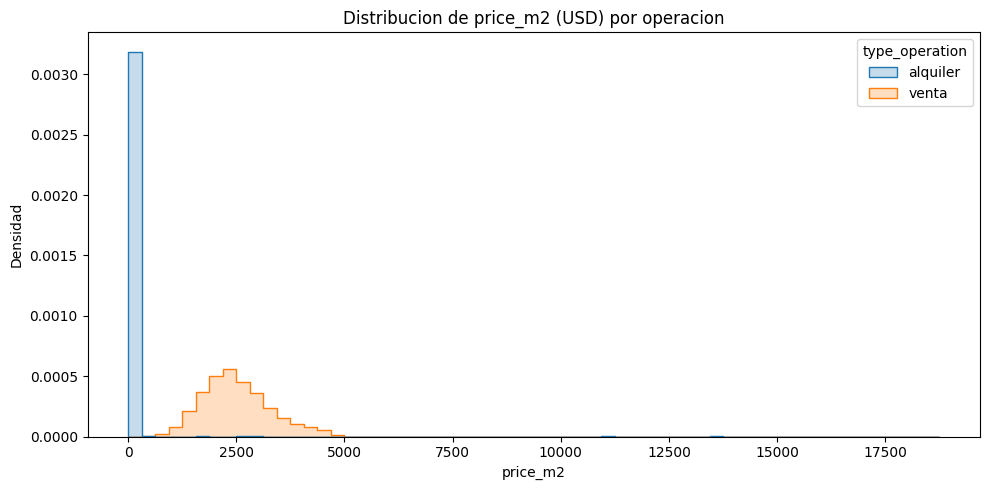

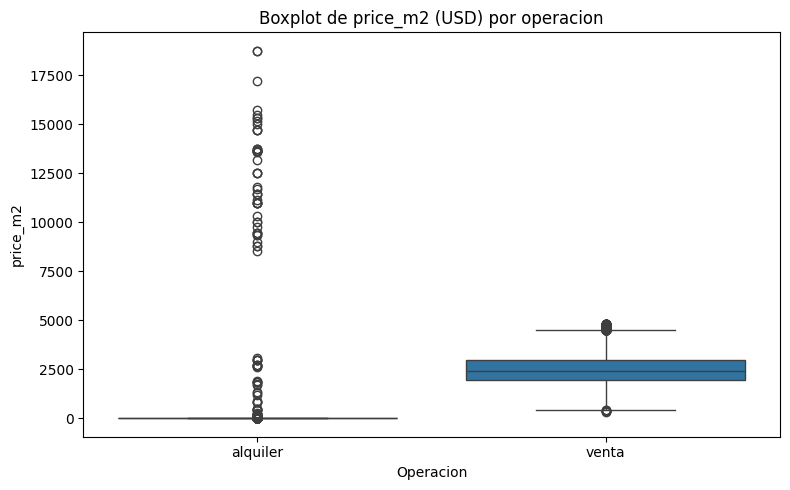

Generados graficos en outputs/graficos/


In [7]:
## Graficos descriptivos

usd = df_final[df_final['currency'].eq('USD')].copy()

# Histograma de price_m2 por operacion
plt.figure(figsize=(10, 5))
sns.histplot(data=usd, x='price_m2', hue='type_operation', bins=60, element='step', stat='density', common_norm=False)
plt.title('Distribucion de price_m2 (USD) por operacion')
plt.xlabel('price_m2')
plt.ylabel('Densidad')
plt.tight_layout()
plt.savefig(out_graficos / '02_hist_price_m2_usd.png', dpi=150)
plt.show()
plt.close()

# Boxplot por operacion
plt.figure(figsize=(8, 5))
sns.boxplot(data=usd, x='type_operation', y='price_m2')
plt.title('Boxplot de price_m2 (USD) por operacion')
plt.xlabel('Operacion')
plt.ylabel('price_m2')
plt.tight_layout()
plt.savefig(out_graficos / '02_box_price_m2_usd.png', dpi=150)
plt.show()
plt.close()

print('Generados graficos en outputs/graficos/')

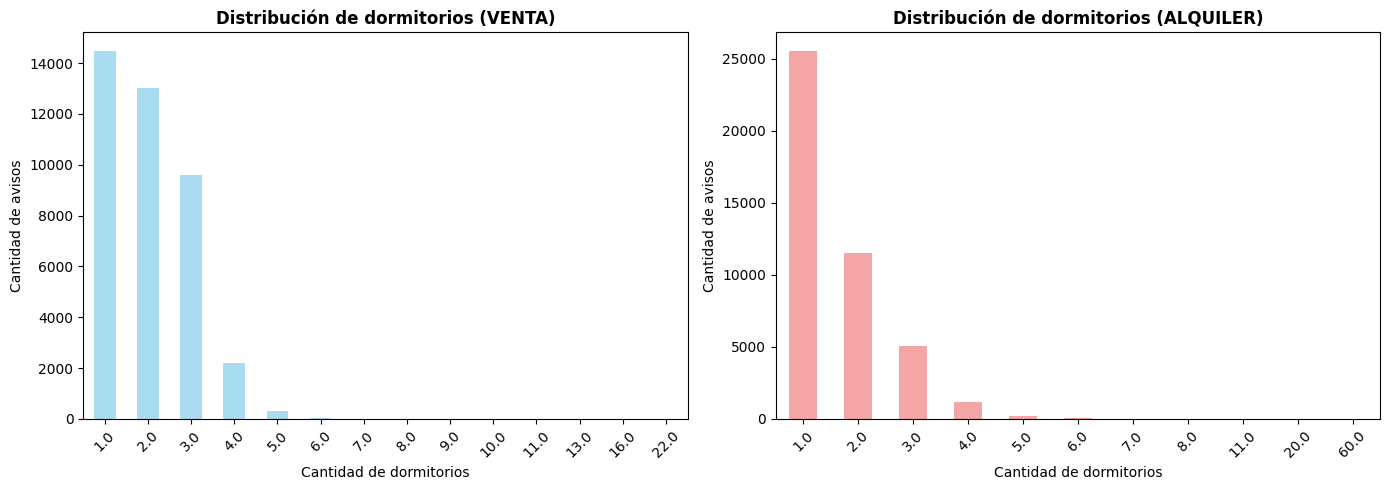

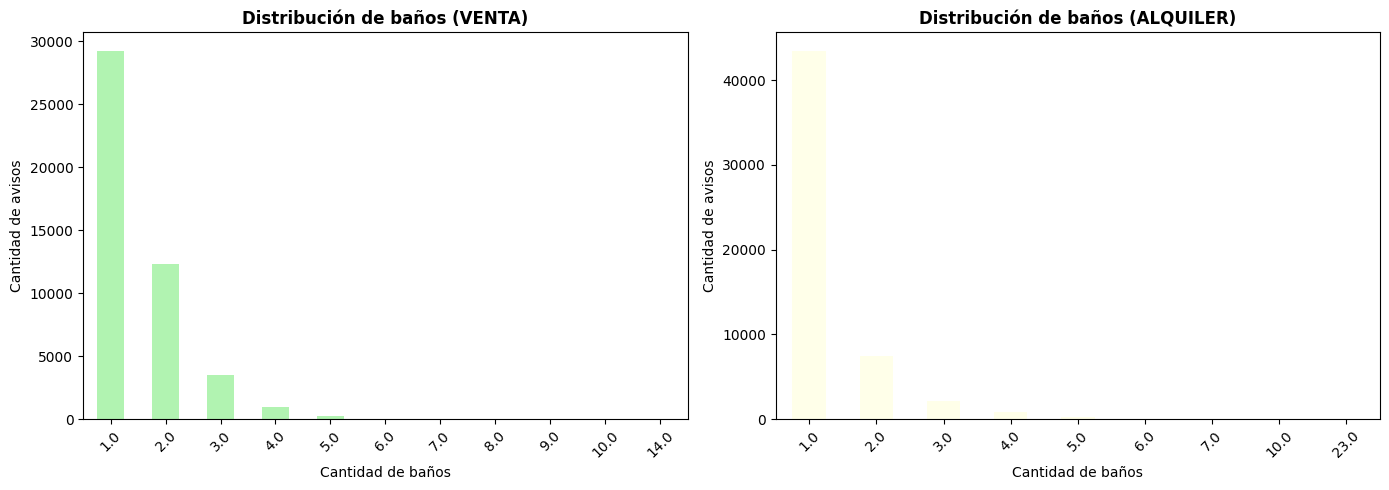

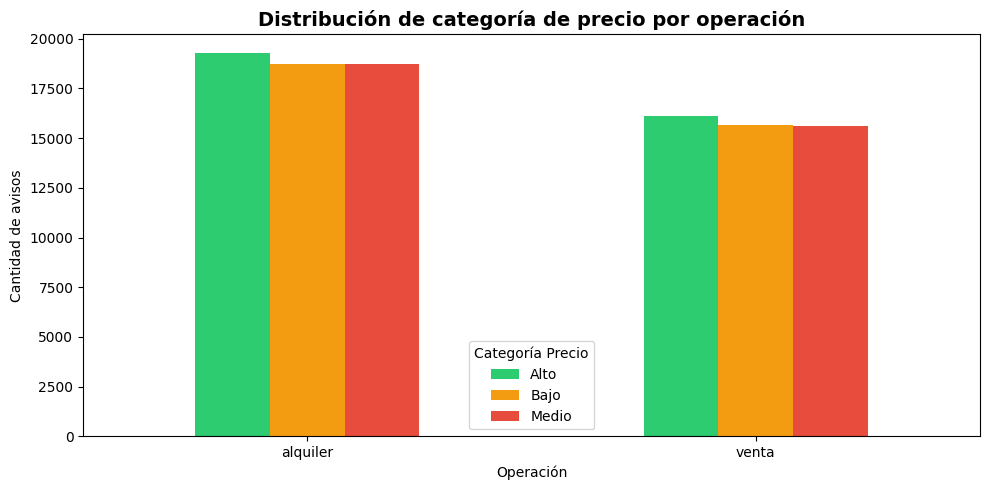

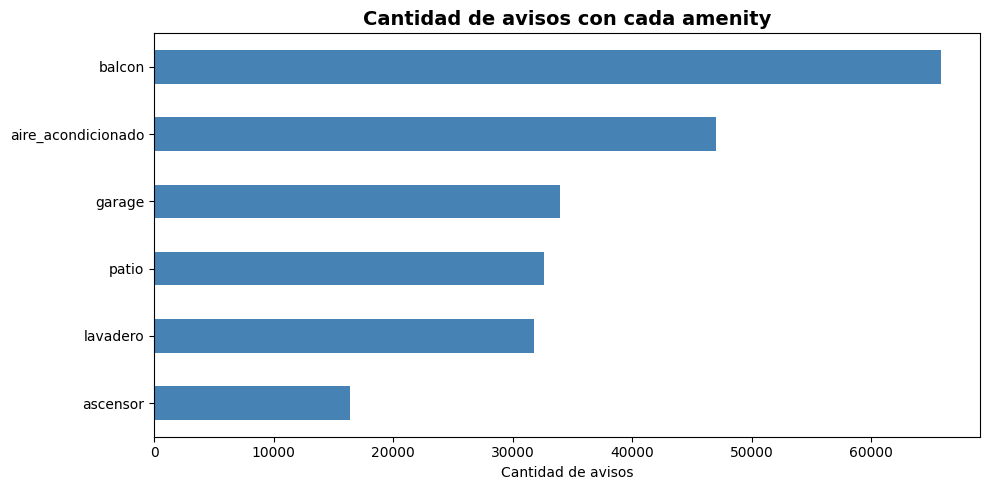

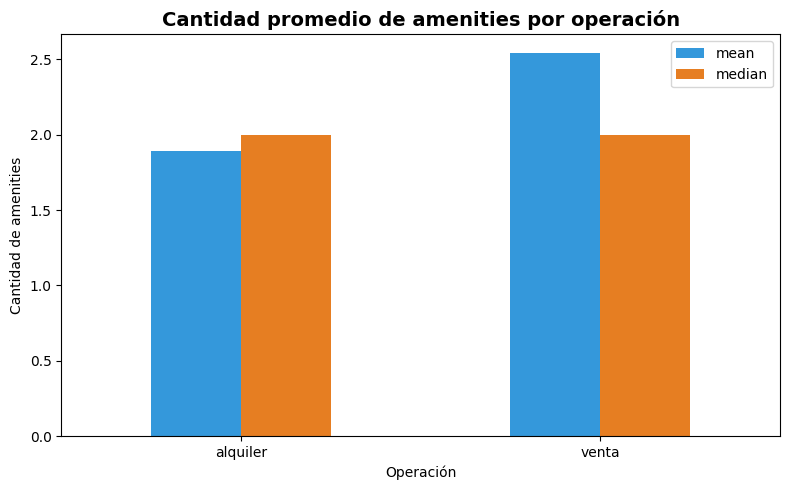

Graficos adicionales generados


In [8]:
## Graficos de variables nuevas

# Distribución de bedrooms por operación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_bed_venta = df_final[df_final['type_operation'] == 'venta']['bedrooms'].value_counts().sort_index()
df_bed_alq = df_final[df_final['type_operation'] == 'alquiler']['bedrooms'].value_counts().sort_index()

df_bed_venta.plot(kind='bar', ax=axes[0], color='skyblue', alpha=0.7)
axes[0].set_title('Distribución de dormitorios (VENTA)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad de dormitorios')
axes[0].set_ylabel('Cantidad de avisos')
axes[0].tick_params(axis='x', rotation=45)

df_bed_alq.plot(kind='bar', ax=axes[1], color='lightcoral', alpha=0.7)
axes[1].set_title('Distribución de dormitorios (ALQUILER)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de dormitorios')
axes[1].set_ylabel('Cantidad de avisos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.close()

# Distribución de bathrooms por operación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_bath_venta = df_final[df_final['type_operation'] == 'venta']['bathrooms'].value_counts().sort_index()
df_bath_alq = df_final[df_final['type_operation'] == 'alquiler']['bathrooms'].value_counts().sort_index()

df_bath_venta.plot(kind='bar', ax=axes[0], color='lightgreen', alpha=0.7)
axes[0].set_title('Distribución de baños (VENTA)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad de baños')
axes[0].set_ylabel('Cantidad de avisos')
axes[0].tick_params(axis='x', rotation=45)

df_bath_alq.plot(kind='bar', ax=axes[1], color='lightyellow', alpha=0.7)
axes[1].set_title('Distribución de baños (ALQUILER)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de baños')
axes[1].set_ylabel('Cantidad de avisos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.close()

# Distribución de categoría de precio por operación
fig, ax = plt.subplots(figsize=(10, 5))
precio_cat_counts = df_final.groupby(['type_operation', 'precio_categoria']).size().unstack(fill_value=0)
precio_cat_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Distribución de categoría de precio por operación', fontsize=14, fontweight='bold')
ax.set_xlabel('Operación')
ax.set_ylabel('Cantidad de avisos')
ax.legend(title='Categoría Precio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

# Distribución de amenities
fig, ax = plt.subplots(figsize=(10, 5))
amenities_count = amenities_df.sum().sort_values(ascending=True)
amenities_count.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Cantidad de avisos con cada amenity', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de avisos')
plt.tight_layout()
plt.show()
plt.close()

# Cantidad de amenities promedio por operación
fig, ax = plt.subplots(figsize=(8, 5))
amenities_promedio = df_final.groupby('type_operation')['cantidad_amenities'].agg(['mean', 'median'])
amenities_promedio.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'])
ax.set_title('Cantidad promedio de amenities por operación', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad de amenities')
ax.set_xlabel('Operación')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

print('Graficos adicionales generados')

## 4. Construir dataset analitico final (ventas USD)

Se construye `datos_filtrados` a partir de `df_final` aplicando filtros de consistencia en variables fisicas y economicas, restringiendo a **venta** en **USD**, y generando `segmento_precio` por terciles empiricos de `price_m2`.

In [9]:
# 4.1 Limpiar datos para el dataset analitico final

datos_filtrados = (
    df_final
    .loc[
        (df_final['type_operation'] == 'venta')
        & (df_final['currency'] == 'USD')
        & (df_final['price_val'] > 100)
        & (df_final['surface_total'] >= 5)
        & (df_final['surface_total'] <= 10000)
        & (df_final['bathrooms'].isna() | ((df_final['bathrooms'] >= 1) & (df_final['bathrooms'] <= 20)))
        & (df_final['garage'].isna() | ((df_final['garage'] >= 0) & (df_final['garage'] < 50)))
        & (df_final['rooms'].isna() | ((df_final['rooms'] >= 1) & (df_final['rooms'] <= 30)))
        & (df_final['bedrooms'].isna() | ((df_final['bedrooms'] >= 0) & (df_final['bedrooms'] <= 15)))
    ]
    .copy()
)

datos_filtrados['price_m2'] = datos_filtrados['price_val'] / datos_filtrados['surface_total']
datos_filtrados = datos_filtrados.loc[
    (datos_filtrados['price_m2'] >= 1) & (datos_filtrados['price_m2'] <= 50000)
].copy()

# Terciles empiricos de price_m2
q_seg = datos_filtrados['price_m2'].quantile([1/3, 2/3])
q33 = q_seg.iloc[0]
q67 = q_seg.iloc[1]

print('Umbrales de segmento_precio (terciles empiricos):')
print(f'  P33 (Economico / Medio): USD {round(q33):,.0f} /m2')
print(f'  P67 (Medio / Premium):   USD {round(q67):,.0f} /m2')

# Segmentacion equivalente al flujo R
datos_filtrados['segmento_precio'] = pd.cut(
    datos_filtrados['price_m2'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Económico', 'Medio', 'Premium'],
    include_lowest=True,
    right=True
)

# Tipado y orden de categorias
if 'type_operation' in datos_filtrados.columns:
    datos_filtrados['type_operation'] = pd.Categorical(
        datos_filtrados['type_operation'],
        categories=['venta', 'alquiler'],
        ordered=True
    )

if 'type_building' in datos_filtrados.columns:
    datos_filtrados['type_building'] = pd.Categorical(
        datos_filtrados['type_building'],
        categories=['departamentos', 'locales-comerciales', 'oficinas-comerciales'],
        ordered=True
    )

if 'zona' in datos_filtrados.columns:
    datos_filtrados['zona'] = pd.Categorical(
        datos_filtrados['zona'],
        categories=['Centro', 'Norte', 'Oeste', 'Sur', 'Otro'],
        ordered=True
    )

# Rango de fechas
if 'scrap_date' in datos_filtrados.columns:
    datos_filtrados['scrap_date'] = pd.to_datetime(datos_filtrados['scrap_date'], errors='coerce')
    fechas = datos_filtrados['scrap_date'].agg(['min', 'max'])
    print('\nRango de fechas del dataset final:')
    print(f"  Desde: {fechas['min']}")
    print(f"  Hasta: {fechas['max']}")

print(f'\nFilas dataset analitico final (ventas USD): {len(datos_filtrados)}')

# Export
out_final = out_interm / '02_datos_filtrados_venta_usd.csv'
datos_filtrados.to_csv(out_final, index=False)
print('Generado:', out_final)

Umbrales de segmento_precio (terciles empiricos):
  P33 (Economico / Medio): USD 2,118 /m2
  P67 (Medio / Premium):   USD 2,763 /m2

Rango de fechas del dataset final:
  Desde: 2024-09-24 14:20:03.244872
  Hasta: 2025-07-12 13:58:06.735039

Filas dataset analitico final (ventas USD): 47302
Generado: outputs/interm/02_datos_filtrados_venta_usd.csv


In [ ]:
## Generacion de reportes

reporte = pd.DataFrame({
    'paso': [
        'input_scope',
        'post_filtros_basicos',
        'post_outliers_iqr_exploratorio',
        'dataset_analitico_final_rmd_venta_usd'
    ],
    'filas': [
        len(df),
        len(df_base),
        len(df_final),
        len(datos_filtrados)
    ]
})
reporte['pct_vs_input'] = (100 * reporte['filas'] / len(df)).round(2)

# Exportes
# df_final se conserva para análisis exploratorio y gráficos
df_final.to_csv(out_interm / '02_df_limpio_base.csv', index=False)
# datos_filtrados es el dataset final válido equivalente al Rmd
datos_filtrados.to_csv(out_interm / '02_datos_filtrados_venta_usd.csv', index=False)
reporte.to_csv(out_tablas / '02_reporte_calidad.csv', index=False)

display(reporte)
print('Generado (exploratorio):', out_interm / '02_df_limpio_base.csv')
print('Generado (final Rmd):', out_interm / '02_datos_filtrados_venta_usd.csv')
print('Generado:', out_tablas / '02_reporte_calidad.csv')

,paso,filas,pct_vs_input
0,input_scope,108034,100.00
1,post_filtros_basicos,107191,99.22
2,post_outliers_iqr,104084,96.34
3,dataset_analitico_venta_usd,47302,43.78


Generado: outputs/interm/02_df_limpio_base.csv
Generado: outputs/interm/02_datos_filtrados_venta_usd.csv
Generado: outputs/tablas/02_reporte_calidad.csv


In [11]:
## Documentacion de variables generadas

nuevas_variables = pd.DataFrame({
    'Variable': [
        'currency',
        'price_val',
        'surface_total',
        'rooms',
        'bedrooms',
        'bathrooms',
        'garage',
        'price_m2',
        'barrio',
        'zona',
        'segmento_precio',
        'cantidad_amenities',
        'amenity_garage',
        'amenity_ascensor',
        'amenity_balcon',
        'amenity_patio',
        'amenity_lavadero',
        'amenity_aire_acondicionado'
    ],
    'Descripcion': [
        'Moneda del precio extraída de Price (USD, ARS, Consultar)',
        'Valor numérico del precio extraído de Price',
        'Superficie total extraída de Features',
        'Cantidad de ambientes extraída de Features',
        'Cantidad de dormitorios extraída de Features',
        'Cantidad de baños extraída de Features',
        'Cantidad de cocheras extraída de Features',
        'Precio por metro cuadrado calculado',
        'Barrio extraído de Location',
        'Macrozona (Centro/Norte/Oeste/Sur/Otro) desde barrio',
        'Terciles de price_m2: Económico (<P33) / Medio (P33-P67) / Premium (>P67)',
        'Cantidad total de amenities detectados',
        'Presencia de garage/cochera/estacionamiento (1/0)',
        'Presencia de ascensor/elevador (1/0)',
        'Presencia de balcon (1/0)',
        'Presencia de patio/terraza (1/0)',
        'Presencia de lavadero/lavanderia (1/0)',
        'Presencia de aire acondicionado (1/0)'
    ],
    'Tipo': [
        'string',
        'float',
        'float',
        'float',
        'float',
        'float',
        'float',
        'float',
        'string',
        'string',
        'string',
        'int',
        'int',
        'int',
        'int',
        'int',
        'int',
        'int'
    ]
})

display(nuevas_variables)
print('\nTotal columnas en dataset final:', df_final.shape[1])
print('Total variables documentadas:', len(nuevas_variables))
print('\nCobertura de variables de Features:')
for col in ['surface_total', 'rooms', 'bedrooms', 'bathrooms', 'garage']:
    nn = int(df_final[col].notna().sum())
    print(f"  {col} no-nulos: {nn} ({round(100 * nn / len(df_final), 1)}%)")
print('\nCobertura de zona:')
print(f"  zona != Otro: {(df_final['zona'] != 'Otro').sum()} ({round(100 * (df_final['zona'] != 'Otro').sum() / len(df_final), 1)}%)")

,Variable,Descripcion,Tipo
0,currency,"Moneda del precio extraída de Price (USD, ARS,...",string
1,price_val,Valor numérico del precio extraído de Price,float
2,surface_total,Superficie total extraída de Features,float
3,rooms,Cantidad de ambientes extraída de Features,float
4,bedrooms,Cantidad de dormitorios extraída de Features,float
5,bathrooms,Cantidad de baños extraída de Features,float
6,garage,Cantidad de cocheras extraída de Features,float
7,price_m2,Precio por metro cuadrado calculado,float
8,barrio,Barrio extraído de Location,string
9,zona,Macrozona (Centro/Norte/Oeste/Sur/Otro) desde ...,string



Total columnas en dataset final: 33
Total variables documentadas: 18

Cobertura de variables de Features:
  surface_total no-nulos: 104084 (100.0%)
  rooms no-nulos: 102856 (98.8%)
  bedrooms no-nulos: 83228 (80.0%)
  bathrooms no-nulos: 100532 (96.6%)
  garage no-nulos: 24546 (23.6%)

Cobertura de zona:
  zona != Otro: 103980 (99.9%)
